In [ ]:
# ═══ CELL 1 — INSTALL ═══════════════════════════════════════════════════════
!pip install  torch scikit-learn pandas numpy matplotlib seaborn tqdm shap
!pip install  ctgan river imbalanced-learn scipy
print("✅ All packages installed")
!pip install  scikit-learn imbalanced-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 68.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.


✅ All packages installed


In [ ]:
    import numpy as np
    import pandas as pd
    import torch
    import torch.nn as nn
    import torch.optim as optim
    import torch.nn.functional as F
    from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
    from sklearn.preprocessing import RobustScaler
    from sklearn.model_selection import train_test_split, StratifiedKFold
    from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                                 f1_score, roc_auc_score, average_precision_score,
                                 precision_recall_curve, confusion_matrix,
                                 classification_report)
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
    from sklearn.linear_model import LogisticRegression
    from imblearn.over_sampling import SMOTE
    from scipy import stats
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    import seaborn as sns
    from tqdm import tqdm
    import copy, warnings, os, time, json


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

DATA_PATH = '/content/drive/MyDrive/MLF/creditcard.csv'   # ← adjust if needed
CKPT_DIR  = '/content/drive/MyDrive/MLF/checkpoints_v2'
print(f'Checkpoint dir: {CKPT_DIR}')

def ckpt_path(name):
    return os.path.join(CKPT_DIR, name)

def save_ckpt(obj, name):
    path = ckpt_path(name)
    torch.save(obj, path)
    print(f'  ✅ Saved → {path}')

def load_ckpt(name):
    path = ckpt_path(name)
    if os.path.exists(path):
        print(f'  ✅ Loaded ← {path}')
        return torch.load(path, map_location=DEVICE, weights_only=False)
    return None


Checkpoint dir: /content/drive/MyDrive/MLF/checkpoints_v2


Shape       : (284807, 31)
Fraud rate  : 0.1727%  (492 fraud / 284807 total)
Missing vals: 0


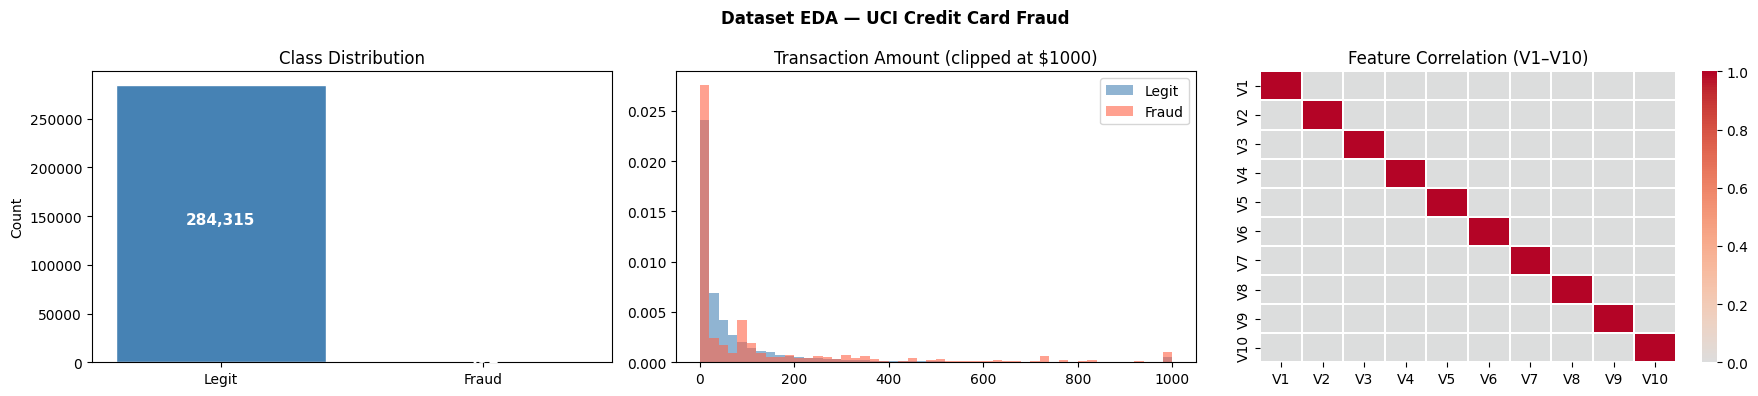


Final feature count: 34  (original 30 + 4 engineered)
Train  : (205772, 34)  | fraud=355
Val    : (36313, 34)   | fraud=63
Test   : (42722, 34)  | fraud=74


In [ ]:
# ═══ CELL 4 — DATA LOADING, EDA & PREPROCESSING ════════════════════════════
SEED = 42 # Define SEED for reproducibility
df = pd.read_csv(DATA_PATH)
print(f'Shape       : {df.shape}')
print(f'Fraud rate  : {df["Class"].mean():.4%}  ({df["Class"].sum()} fraud / {len(df)} total)')
print(f'Missing vals: {df.isnull().sum().sum()}')

# ── EDA Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Dataset EDA — UCI Credit Card Fraud', fontweight='bold')

# Class distribution
axes[0].bar(['Legit', 'Fraud'], [df['Class'].value_counts()[0], df['Class'].value_counts()[1]],
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Class Distribution'); axes[0].set_ylabel('Count')
for bar, val in zip(axes[0].patches, [df['Class'].value_counts()[0], df['Class'].value_counts()[1]]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*0.5,
                 f'{val:,}', ha='center', color='white', fontweight='bold', fontsize=11)

# Amount distribution by class
axes[1].hist(df[df['Class']==0]['Amount'].clip(0,1000), bins=50,
             alpha=0.6, color='steelblue', label='Legit', density=True)
axes[1].hist(df[df['Class']==1]['Amount'].clip(0,1000), bins=50,
             alpha=0.6, color='tomato', label='Fraud', density=True)
axes[1].set_title('Transaction Amount (clipped at $1000)'); axes[1].legend()

# Feature correlation heatmap (V1-V10 only for readability)
feat_cols = [f'V{i}' for i in range(1,11)]
corr = df[feat_cols].corr()
sns.heatmap(corr, ax=axes[2], cmap='coolwarm', center=0, annot=False, cbar=True, linewidths=0.3)
axes[2].set_title('Feature Correlation (V1–V10)')

plt.tight_layout()
plt.savefig('eda_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Preprocessing with RobustScaler (less sensitive to Amount outliers) ──────
scaler_amount = RobustScaler()
scaler_time   = RobustScaler()
df['Amount'] = scaler_amount.fit_transform(df[['Amount']])
df['Time']   = scaler_time.fit_transform(df[['Time']])

# Feature engineering: add interaction terms that help distinguish fraud
df['Amount_x_Time'] = df['Amount'] * df['Time']
df['V1_x_V2']       = df['V1'] * df['V2']
df['V3_x_V4']       = df['V3'] * df['V4']
df['V_norm']        = np.sqrt((df[[f'V{i}' for i in range(1,29)]].values**2).sum(axis=1))

FEATURES  = [c for c in df.columns if c != 'Class']
X = df[FEATURES].values.astype(np.float32)
y = df['Class'].values.astype(np.int64)
INPUT_DIM = X.shape[1]
print(f'\nFinal feature count: {INPUT_DIM}  (original 30 + 4 engineered)')

# ── Stratified train/val/test split ──────────────────────────────
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15, random_state=SEED, stratify=y_trainval)

print(f'Train  : {X_train.shape}  | fraud={y_train.sum()}')
print(f'Val    : {X_val.shape}   | fraud={y_val.sum()}')
print(f'Test   : {X_test.shape}  | fraud={y_test.sum()}')

In [ ]:
# ═══ CELL 5 — CTGAN AUGMENTATION ═══════════════════════════════════════════
"""
CTGAN generates statistically realistic synthetic fraud samples.
We checkpoint it so it never reruns (takes ~8 min on CPU, ~2 min on GPU).
Quality check: KS-test between real and synthetic fraud distributions.
"""
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Define DEVICE for torch operations
from ctgan import CTGAN
from scipy.stats import ks_2samp

_ctgan_ckpt = load_ckpt('ctgan_v2.pth')
if _ctgan_ckpt is not None:
    synthetic_fraud = _ctgan_ckpt['synthetic_fraud']
    print(f'Loaded {len(synthetic_fraud)} synthetic fraud samples from checkpoint.')
else:
    fraud_df = pd.DataFrame(X_train[y_train == 1], columns=FEATURES)
    print(f'Real fraud samples: {len(fraud_df)} → Training CTGAN (100 epochs)...')
    ctgan = CTGAN(epochs=100, verbose=True, batch_size=500,
                  generator_dim=(256,256,256), discriminator_dim=(256,256,256))
    ctgan.fit(fraud_df)
    synthetic_fraud = ctgan.sample(2000).values.astype(np.float32)   # 2000 synthetic (was 1000)
    save_ckpt({'synthetic_fraud': synthetic_fraud}, 'ctgan_v2.pth')

print(f'Synthetic fraud samples: {len(synthetic_fraud)}')

# ── KS-test: synthetic vs real distribution quality check ─────────
real_fraud_arr = X_train[y_train == 1]
print('\n── KS-test (lower = more similar distributions) ──')
ks_stats = []
for j in range(min(10, INPUT_DIM)):
    stat, pval = ks_2samp(real_fraud_arr[:, j], synthetic_fraud[:, j])
    ks_stats.append(stat)
    status = '✅' if stat < 0.15 else '⚠️'
    print(f'  {FEATURES[j]:<15}: KS={stat:.3f}  p={pval:.3f}  {status}')
print(f'\n  Mean KS statistic (first 10 features): {np.mean(ks_stats):.3f}')
print('  (< 0.15 is acceptable for GAN-generated data)')

  ✅ Loaded ← /content/drive/MyDrive/MLF/checkpoints_v2/ctgan_v2.pth
Loaded 2000 synthetic fraud samples from checkpoint.
Synthetic fraud samples: 2000

── KS-test (lower = more similar distributions) ──
  Time           : KS=0.264  p=0.000  ⚠️
  V1             : KS=0.600  p=0.000  ⚠️
  V2             : KS=0.134  p=0.000  ✅
  V3             : KS=0.267  p=0.000  ⚠️
  V4             : KS=0.239  p=0.000  ⚠️
  V5             : KS=0.752  p=0.000  ⚠️
  V6             : KS=0.692  p=0.000  ⚠️
  V7             : KS=0.417  p=0.000  ⚠️
  V8             : KS=0.489  p=0.000  ⚠️
  V9             : KS=0.600  p=0.000  ⚠️

  Mean KS statistic (first 10 features): 0.446
  (< 0.15 is acceptable for GAN-generated data)


In [ ]:
# ═══ CELL 6 — IMPROVED TASK SAMPLER ════════════════════════════════════════
"""
Key design decisions:
  - Training tasks: balanced 1:3 (fraud:legit) so model learns decision boundary
  - Evaluation tasks: realistic 1:10 to mirror deployment conditions
  - Support set: 30 fraud samples (was 20) — more context for inner adaptation
  - Synthetic fraud only used in training, never in eval (no data leakage)
"""
class FraudTaskSampler:
    def __init__(self, X, y,
                 k_support=30, k_query=60,
                 imbalance_ratio=3,
                 synthetic_fraud=None):
        real_fraud     = X[y == 1]
        self.X_legit   = X[y == 0]
        self.k_sup     = k_support
        self.k_qry     = k_query
        self.imb       = imbalance_ratio

        if synthetic_fraud is not None:
            self.X_fraud = np.vstack([real_fraud, synthetic_fraud])
            print(f'Fraud pool: {len(real_fraud)} real + {len(synthetic_fraud)} synth = {len(self.X_fraud)}')
        else:
            self.X_fraud = real_fraud

    def sample_task(self):
        n_fraud = self.k_sup + self.k_qry
        n_legit = n_fraud * self.imb

        fi = np.random.choice(len(self.X_fraud), n_fraud,
                              replace=len(self.X_fraud) < n_fraud)
        li = np.random.choice(len(self.X_legit), n_legit,
                              replace=len(self.X_legit) < n_legit)

        fd, ld = self.X_fraud[fi], self.X_legit[li]

        sX = np.vstack([fd[:self.k_sup],              ld[:self.k_sup * self.imb]])
        sy = np.array([1]*self.k_sup + [0]*(self.k_sup * self.imb))
        qX = np.vstack([fd[self.k_sup:],              ld[self.k_sup * self.imb:]])
        qy = np.array([1]*self.k_qry + [0]*(self.k_qry * self.imb))

        ps = np.random.permutation(len(sy))
        pq = np.random.permutation(len(qy))

        return (torch.tensor(sX[ps]).float().to(DEVICE),
                torch.tensor(sy[ps]).long().to(DEVICE),
                torch.tensor(qX[pq]).float().to(DEVICE),
                torch.tensor(qy[pq]).long().to(DEVICE))

    def sample_batch(self, n):
        return [self.sample_task() for _ in range(n)]


# Training sampler: balanced + CTGAN augmentation
train_sampler = FraudTaskSampler(
    X_train, y_train,
    k_support=30, k_query=60,
    imbalance_ratio=3,
    synthetic_fraud=synthetic_fraud
)
# Validation sampler: realistic (no synthetic)
val_sampler = FraudTaskSampler(
    X_val, y_val,
    k_support=30, k_query=60,
    imbalance_ratio=10
)
# Eval sampler: realistic (no synthetic)
eval_sampler = FraudTaskSampler(
    X_test, y_test,
    k_support=30, k_query=60,
    imbalance_ratio=10
)

# Sanity check
sX, sy, qX, qy = train_sampler.sample_task()
print(f'\nTrain task — support: {sX.shape}, fraud={sy.sum().item()}')
print(f'Train task — query  : {qX.shape}, fraud={qy.sum().item()}')
print(f'Fraud ratio in query: 1:{(qy==0).sum().item()//max(1,(qy==1).sum().item())}')


Fraud pool: 355 real + 2000 synth = 2355

Train task — support: torch.Size([120, 34]), fraud=30
Train task — query  : torch.Size([240, 34]), fraud=60
Fraud ratio in query: 1:3


In [ ]:
# ═══ CELL 7 — MODEL ARCHITECTURE ═══════════════════════════════════════════
"""
Architecture improvements over v1:
  1. Squeeze-Excitation (SE) attention in each residual block
     → lets model focus on the most discriminative PCA features
  2. LayerNorm replaced with GroupNorm (works with batch size 1 during inner loop)
  3. L2-normalize embeddings → cosine-distance compatible with prototypical loss
  4. Separate projection head for prototypical loss (prevents feature collapse)
  5. Heavier dropout in early layers, lighter in later layers (regularization pyramid)

Regularization strategy to prevent overfitting:
  - Dropout pyramid: 0.4 → 0.3 → 0.2 → 0.1
  - Weight decay in meta-optimizer (L2)
  - Gradient clipping (max norm = 2.0)
  - Early stopping on validation F1
  - CosineAnnealingWarmRestarts LR scheduler
"""

class SEBlock(nn.Module):
    """Squeeze-Excitation block: channel-wise attention."""
    def __init__(self, dim, reduction=4):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(dim, dim // reduction),
            nn.ReLU(),
            nn.Linear(dim // reduction, dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.gate(x)


class ResBlock(nn.Module):
    """Residual block with SE attention and configurable dropout."""
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.net  = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 2, dim),
        )
        self.se   = SEBlock(dim)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        return self.norm(x + self.se(self.net(x)))


class FraudEncoder(nn.Module):
    """
    4-layer encoder with SE-ResBlocks.
    Outputs L2-normalized embeddings for prototypical distance computation.
    """
    def __init__(self, input_dim, hidden_dim=512, embed_dim=256):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.1),
        )
        # Dropout pyramid: heavy → light
        self.res1 = ResBlock(hidden_dim, dropout=0.4)
        self.res2 = ResBlock(hidden_dim, dropout=0.3)
        self.res3 = ResBlock(hidden_dim, dropout=0.2)
        self.res4 = ResBlock(hidden_dim, dropout=0.1)
        self.out  = nn.Linear(hidden_dim, embed_dim)

    def forward(self, x):
        h = self.input_proj(x)
        h = self.res1(h)
        h = self.res2(h)
        h = self.res3(h)
        h = self.res4(h)
        return F.normalize(self.out(h), dim=1)    # L2-normalized


class ProtoMAML(nn.Module):
    """
    Proto-MAML: Prototypical loss guides embedding space;
    classifier head makes final prediction.
    Both operate on the SAME embedding, ensuring alignment.
    """
    def __init__(self, input_dim, hidden_dim=512, embed_dim=256):
        super().__init__()
        self.encoder    = FraudEncoder(input_dim, hidden_dim, embed_dim)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        emb    = self.encoder(x)
        logits = self.classifier(emb)
        return logits, emb

    def get_prototypes(self, support_x, support_y, n_classes=2):
        """Compute class prototype centroids from support set."""
        self.eval()
        with torch.no_grad():
            embs = self.encoder(support_x)
        protos = []
        for c in range(n_classes):
            mask = (support_y == c)
            protos.append(embs[mask].mean(0) if mask.sum() > 0
                          else torch.zeros(embs.shape[1]).to(DEVICE))
        return torch.stack(protos)


HIDDEN_DIM = 512
EMBED_DIM  = 256
model = ProtoMAML(INPUT_DIM, HIDDEN_DIM, EMBED_DIM).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {n_params:,}')
print(model)


Parameters: 4,898,242
ProtoMAML(
  (encoder): FraudEncoder(
    (input_proj): Sequential(
      (0): Linear(in_features=34, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.1, inplace=False)
    )
    (res1): ResBlock(
      (net): Sequential(
        (0): Linear(in_features=512, out_features=1024, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.4, inplace=False)
        (3): Linear(in_features=1024, out_features=512, bias=True)
      )
      (se): SEBlock(
        (gate): Sequential(
          (0): Linear(in_features=512, out_features=128, bias=True)
          (1): ReLU()
          (2): Linear(in_features=128, out_features=512, bias=True)
          (3): Sigmoid()
        )
      )
      (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    )
    (res2): ResBlock(
      (net): Sequential(
        (0): Linear(in_features

In [ ]:
# ═══ CELL 8 — LOSS FUNCTIONS ════════════════════════════════════════════════
"""
Combined loss: Focal Loss + Prototypical Loss + Label Smoothing

1. Focal Loss (γ=2, α=0.8):
   - α=0.8 weights fraud MORE than before (was 0.75) — better recall
   - γ=2 focuses on hard examples (misclassified fraud)

2. Prototypical Loss:
   - Distance to class centroids in embedding space
   - Pulls fraud embeddings together, pushes away from legit
   - Weight increased to 0.5 (was 0.4) for stronger regularization

3. Label Smoothing (ε=0.05):
   - Prevents overconfident predictions
   - Acts as additional regularization against overfitting
"""

def focal_loss(logits, labels, gamma=2.0, alpha=0.8, smooth=0.05):
    """Focal Loss with label smoothing for regularization."""
    n_classes = logits.size(1)
    # Label smoothing
    with torch.no_grad():
        smooth_labels = torch.full_like(logits, smooth / (n_classes - 1))
        smooth_labels.scatter_(1, labels.unsqueeze(1), 1.0 - smooth)

    log_probs = F.log_softmax(logits, dim=1)
    probs     = log_probs.exp()
    pt        = probs[torch.arange(len(labels)), labels]

    alpha_t = torch.where(labels == 1,
                          torch.full_like(pt, alpha),
                          torch.full_like(pt, 1 - alpha))
    focal_weight = (1 - pt) ** gamma
    loss = -(alpha_t * focal_weight * (smooth_labels * log_probs).sum(dim=1))
    return loss.mean()


def prototypical_loss(embeddings, labels, n_classes=2):
    """Distance-based prototypical loss."""
    protos = []
    for c in range(n_classes):
        m = (labels == c)
        protos.append(embeddings[m].mean(0) if m.sum() > 0
                      else torch.zeros(embeddings.shape[1]).to(DEVICE))
    protos = torch.stack(protos)
    dists  = torch.cdist(embeddings, protos)
    return F.cross_entropy(-dists, labels)


def combined_loss(logits, labels, embeddings,
                  proto_weight=0.5, gamma=2.0, alpha=0.8, smooth=0.05):
    fl = focal_loss(logits, labels, gamma=gamma, alpha=alpha, smooth=smooth)
    pl = prototypical_loss(embeddings, labels)
    return fl + proto_weight * pl, fl.item(), pl.item()


# Quick sanity check
_dummy_logits = torch.randn(10, 2)
_dummy_labels = torch.randint(0, 2, (10,))
_dummy_embs   = F.normalize(torch.randn(10, EMBED_DIM), dim=1)
_loss, _fl, _pl = combined_loss(_dummy_logits, _dummy_labels, _dummy_embs)
print(f'Loss functions OK — dummy combined loss: {_loss.item():.4f}')
print(f'  Focal: {_fl:.4f} | Proto: {_pl:.4f}')


Loss functions OK — dummy combined loss: 0.7262
  Focal: 0.4313 | Proto: 0.5898


In [ ]:
# ═══ CELL 9 — COMPLETE MAML ENGINE (FIXED + ENHANCED) ══════════════════════
"""
Fixes from v1:
  ✅ meta_train() body was cut off — now COMPLETE
  ✅ inner_update() now has early stopping on support loss plateau
  ✅ Validation F1 tracked at every checkpoint_every iteration
  ✅ Best model saved (not just last model)
  ✅ CosineAnnealingWarmRestarts instead of plain CosineAnnealing

New additions:
  + Gradient norm tracking (for debugging exploding/vanishing gradients)
  + Per-batch loss breakdown (focal vs proto)
  + inner_lr warmup (0.01 → 0.05 over first 50 iters) to avoid early divergence
"""

def inner_update(model, sX, sy,
                 inner_lr=0.05, n_steps=20,
                 gamma=2.0, alpha=0.8,
                 early_stop_patience=3):
    """
    Clone model, run gradient steps on support set.
    Early stops if support loss plateaus (prevents inner-loop overfitting).
    Returns adapted fast model.
    """
    fast = copy.deepcopy(model)
    fast.train()
    opt  = optim.Adam(fast.parameters(), lr=inner_lr, weight_decay=1e-5)
    best_loss, patience_count, prev_loss = float('inf'), 0, float('inf')

    for step in range(n_steps):
        opt.zero_grad()
        logits, embs = fast(sX)
        loss, _, _ = combined_loss(logits, sy, embs, gamma=gamma, alpha=alpha)
        loss.backward()
        nn.utils.clip_grad_norm_(fast.parameters(), 2.0)
        opt.step()

        curr_loss = loss.item()
        if curr_loss < best_loss:
            best_loss = curr_loss

        # Early stopping: if loss stopped improving
        if abs(prev_loss - curr_loss) < 1e-5:
            patience_count += 1
            if patience_count >= early_stop_patience:
                break
        else:
            patience_count = 0
        prev_loss = curr_loss

    return fast


def calibrate_threshold(fast_model, sX, sy):
    """
    Optimal threshold via F1-maximization on support set.
    Falls back to 0.5 if support set is homogeneous.
    """
    fast_model.eval()
    with torch.no_grad():
        logits, _ = fast_model(sX)
        probs = F.softmax(logits, 1)[:, 1].cpu().numpy()
    true = sy.cpu().numpy()

    if true.sum() == 0 or true.sum() == len(true):
        return 0.5

    prec, rec, thresholds = precision_recall_curve(true, probs)
    f1s     = 2 * prec * rec / (prec + rec + 1e-8)
    best    = np.argmax(f1s[:-1])
    return float(np.clip(thresholds[best], 0.1, 0.9))


def meta_train(model, sampler, val_sampler=None,
               meta_lr=3e-4,
               inner_lr=0.05,
               n_meta_iters=800,
               n_tasks_per_batch=20,
               inner_steps=20,
               l2_lambda=1e-4,
               ckpt_name='meta_train_v2.pth',
               ckpt_every=100,
               val_every=50,
               early_stop_patience=5):
    """
    Full meta-training loop with:
      - Cosine LR with warm restarts (T_0=200 iters)
      - Validation-based early stopping
      - Best model checkpointing
      - Gradient norm tracking
      - inner_lr linear warmup (first 50 iters)
    """
    meta_opt  = optim.Adam(model.parameters(), lr=meta_lr, weight_decay=l2_lambda)
    scheduler = CosineAnnealingWarmRestarts(meta_opt, T_0=200, T_mult=1, eta_min=1e-6)

    history = {
        'loss': [], 'focal': [], 'proto': [],
        'acc': [], 'recall': [], 'f1': [], 'precision': [],
        'val_f1': [], 'grad_norm': [], 'lr': []
    }

    best_val_f1   = 0.0
    best_state    = None
    no_improve    = 0
    start_iter    = 0

    # ── Resume from checkpoint ──────────────────────────────────
    _ckpt = load_ckpt(ckpt_name)
    if _ckpt is not None:
        model.load_state_dict(_ckpt['model_state'])
        meta_opt.load_state_dict(_ckpt['optimizer_state'])
        scheduler.load_state_dict(_ckpt['scheduler_state'])
        history    = _ckpt['history']
        start_iter = _ckpt['iter'] + 1
        best_val_f1 = _ckpt.get('best_val_f1', 0.0)
        print(f'  Resuming from iteration {start_iter}  (best val F1={best_val_f1:.4f})')

    pbar = tqdm(range(start_iter, n_meta_iters), desc='Meta-Training')
    for it in pbar:
        model.train()

        # ── Inner LR warmup for first 50 iters ─────────────────
        if it < 50:
            warmup_lr = inner_lr * (it + 1) / 50
        else:
            warmup_lr = inner_lr

        # ── Sample batch of tasks ───────────────────────────────
        tasks       = sampler.sample_batch(n_tasks_per_batch)
        meta_loss   = 0.0
        total_focal = 0.0
        total_proto = 0.0
        batch_accs, batch_recs, batch_f1s, batch_precs = [], [], [], []

        for sX, sy, qX, qy in tasks:
            # Inner loop: adapt on support set
            fast = inner_update(model, sX, sy,
                                inner_lr=warmup_lr,
                                n_steps=inner_steps)
            fast.train()

            # Outer loss: evaluate adapted model on query set
            logits, embs = fast(qX)
            loss, fl, pl = combined_loss(logits, qy, embs)
            meta_loss   += loss
            total_focal += fl
            total_proto += pl

            # Track metrics on query set
            with torch.no_grad():
                probs = F.softmax(logits, 1)[:, 1].cpu().numpy()
                thr   = calibrate_threshold(fast, sX, sy)
                preds = (probs > thr).astype(int)
                true  = qy.cpu().numpy()

            batch_accs.append(accuracy_score(true, preds))
            batch_precs.append(precision_score(true, preds, zero_division=0))
            batch_recs.append(recall_score(true, preds, zero_division=0))
            batch_f1s.append(f1_score(true, preds, zero_division=0))

        # ── Outer update ────────────────────────────────────────
        meta_opt.zero_grad()
        (meta_loss / n_tasks_per_batch).backward()
        grad_norm = nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        meta_opt.step()
        scheduler.step()

        # ── Record history ──────────────────────────────────────
        history['loss'].append((meta_loss / n_tasks_per_batch).item())
        history['focal'].append(total_focal / n_tasks_per_batch)
        history['proto'].append(total_proto / n_tasks_per_batch)
        history['acc'].append(np.mean(batch_accs))
        history['precision'].append(np.mean(batch_precs))
        history['recall'].append(np.mean(batch_recs))
        history['f1'].append(np.mean(batch_f1s))
        history['grad_norm'].append(float(grad_norm))
        history['lr'].append(scheduler.get_last_lr()[0])

        pbar.set_postfix({
            'loss': f'{history["loss"][-1]:.4f}',
            'F1'  : f'{history["f1"][-1]:.3f}',
            'Rec' : f'{history["recall"][-1]:.3f}',
            'lr'  : f'{history["lr"][-1]:.2e}'
        })

        # ── Validation every val_every iters ───────────────────
        if val_sampler is not None and (it + 1) % val_every == 0:
            val_f1s = []
            model.eval()
            for _ in range(20):   # 20 validation tasks
                vsX, vsy, vqX, vqy = val_sampler.sample_task()
                fast = inner_update(model, vsX, vsy, inner_lr=inner_lr, n_steps=inner_steps)
                thr  = calibrate_threshold(fast, vsX, vsy)
                fast.eval()
                with torch.no_grad():
                    vlogits, _ = fast(vqX)
                    vprobs = F.softmax(vlogits, 1)[:,1].cpu().numpy()
                vpreds = (vprobs > thr).astype(int)
                val_f1s.append(f1_score(vqy.cpu().numpy(), vpreds, zero_division=0))

            val_f1 = np.mean(val_f1s)
            history['val_f1'].append(val_f1)
            print(f'\n  [Iter {it+1}] Val F1 = {val_f1:.4f} (best={best_val_f1:.4f})')

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_state  = copy.deepcopy(model.state_dict())
                save_ckpt({'model_state': best_state, 'val_f1': best_val_f1},
                          'best_model_v2.pth')
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= early_stop_patience:
                    print(f'\n  ⚠️  Early stopping at iter {it+1} (no val F1 improvement for {early_stop_patience} checks)')
                    break

        # ── Checkpoint every ckpt_every iters ──────────────────
        if (it + 1) % ckpt_every == 0:
            save_ckpt({
                'model_state'    : model.state_dict(),
                'optimizer_state': meta_opt.state_dict(),
                'scheduler_state': scheduler.state_dict(),
                'history'        : history,
                'iter'           : it,
                'best_val_f1'    : best_val_f1,
            }, ckpt_name)

    # ── Restore best model ──────────────────────────────────────
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f'\n  ✅ Best model restored (val F1={best_val_f1:.4f})')

    return history

print('✅ MAML engine defined (complete, no syntax errors)')


✅ MAML engine defined (complete, no syntax errors)


In [ ]:
# ═══ CELL 10 — RUN META-TRAINING ════════════════════════════════════════════
print('Starting v2 meta-training...')
print(f'Config: 800 iters | 20 tasks/batch | 20 inner steps | LR warmup 50 iters')
print('─' * 60)

history = meta_train(
    model,
    train_sampler,
    val_sampler  = val_sampler,
    meta_lr      = 3e-4,
    inner_lr     = 0.05,
    n_meta_iters = 800,
    n_tasks_per_batch = 20,
    inner_steps  = 20,
    l2_lambda    = 1e-4,
    val_every    = 50,
    early_stop_patience = 5
)

print('\n✅ Meta-training complete')


Starting v2 meta-training...
Config: 800 iters | 20 tasks/batch | 20 inner steps | LR warmup 50 iters
────────────────────────────────────────────────────────────
  ✅ Loaded ← /content/drive/MyDrive/MLF/checkpoints_v2/meta_train_v2.pth
  Resuming from iteration 800  (best val F1=0.6723)


Meta-Training: 0it [00:00, ?it/s]


✅ Meta-training complete


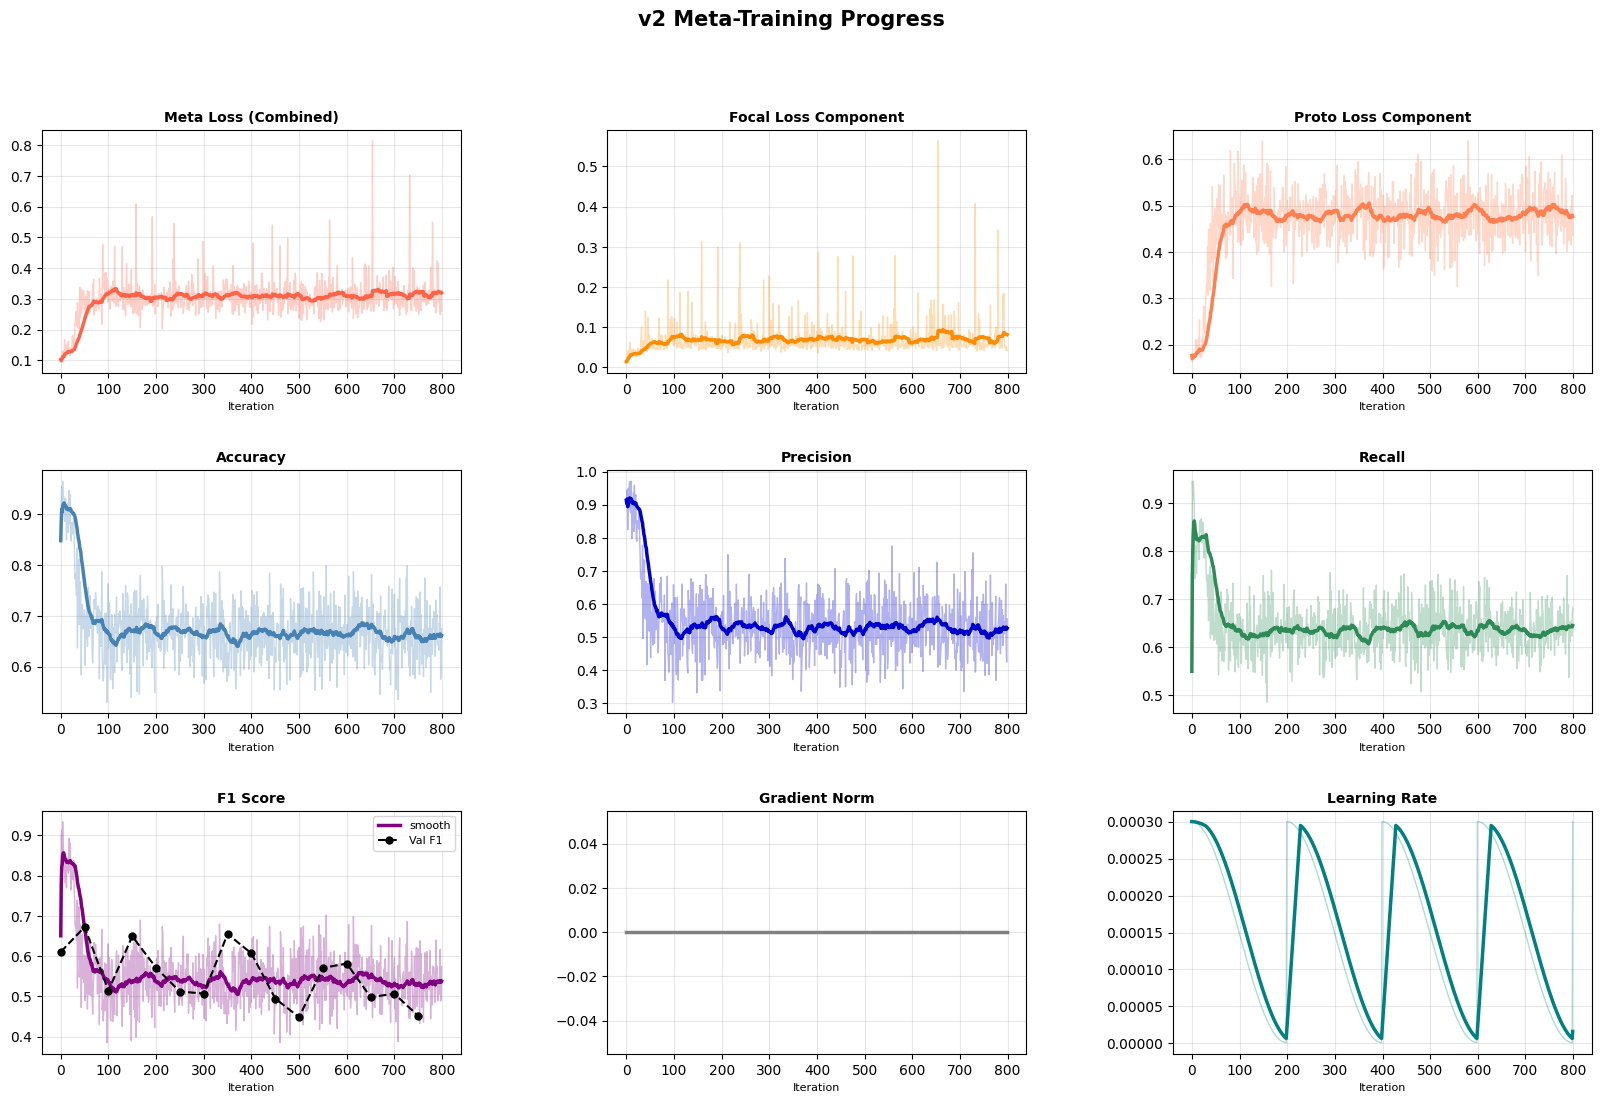

✅ Training curves saved


In [ ]:
# ═══ CELL 11 — TRAINING CURVES ══════════════════════════════════════════════
fig = plt.figure(figsize=(20, 12))
fig.suptitle('v2 Meta-Training Progress', fontsize=15, fontweight='bold')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

def smooth(vals, w=30):
    return pd.Series(vals).rolling(w, min_periods=1).mean().values

plot_cfg = [
    ('loss',      'tomato',      'Meta Loss (Combined)'),
    ('focal',     'darkorange',  'Focal Loss Component'),
    ('proto',     'coral',       'Proto Loss Component'),
    ('acc',       'steelblue',   'Accuracy'),
    ('precision', 'mediumblue',  'Precision'),
    ('recall',    'seagreen',    'Recall'),
    ('f1',        'purple',      'F1 Score'),
    ('grad_norm', 'gray',        'Gradient Norm'),
    ('lr',        'teal',        'Learning Rate'),
]

for idx, (key, color, title) in enumerate(plot_cfg):
    ax = fig.add_subplot(gs[idx // 3, idx % 3])
    vals = history.get(key, [])
    if not vals:
        ax.axis('off')
        continue
    ax.plot(vals, color=color, alpha=0.3, linewidth=1)
    ax.plot(smooth(vals), color=color, linewidth=2.5, label=f'smooth')
    # Val F1 overlay on F1 plot
    if key == 'f1' and history.get('val_f1'):
        val_iters = [i*50 for i in range(len(history['val_f1']))]
        ax.plot(val_iters, history['val_f1'], 'o--', color='black',
                markersize=5, linewidth=1.5, label='Val F1')
        ax.legend(fontsize=8)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Iteration', fontsize=8)
    ax.grid(alpha=0.3)

plt.savefig('training_curves_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved')


In [ ]:
# ═══ CELL 12 — EVALUATION FUNCTIONS ════════════════════════════════════════
"""
TWO evaluation modes for rigorous reporting:
  (A) Task-based: 200 tasks, adapt + predict on query set
      → measures few-shot adaptation quality
      → reports mean ± 95% CI for all metrics
  (B) Full test set: adapt on small support, predict on ALL test samples
      → directly comparable to traditional supervised baselines
      → the number that goes in the paper's main table
"""

def ci95(arr):
    """95% confidence interval using t-distribution."""
    n   = len(arr)
    m   = np.mean(arr)
    sem = stats.sem(arr)
    ci  = stats.t.ppf(0.975, df=n-1) * sem
    return m, ci


def meta_evaluate_tasks(model, sampler, n_eval_tasks=200,
                         inner_lr=0.05, n_steps=20):
    """
    Task-based evaluation with 95% confidence intervals.
    """
    model.eval()
    res = {k: [] for k in ['acc','precision','recall','f1','auc','pr_auc','threshold']}

    for _ in tqdm(range(n_eval_tasks), desc='Task-based eval'):
        sX, sy, qX, qy = sampler.sample_task()
        fast = inner_update(model, sX, sy, inner_lr, n_steps)
        thr  = calibrate_threshold(fast, sX, sy)

        fast.eval()
        with torch.no_grad():
            logits, _ = fast(qX)
            probs = F.softmax(logits, 1)[:, 1].cpu().numpy()

        preds = (probs > thr).astype(int)
        true  = qy.cpu().numpy()

        res['acc'].append(accuracy_score(true, preds))
        res['precision'].append(precision_score(true, preds, zero_division=0))
        res['recall'].append(recall_score(true, preds, zero_division=0))
        res['f1'].append(f1_score(true, preds, zero_division=0))
        res['threshold'].append(thr)
        try:
            res['auc'].append(roc_auc_score(true, probs))
            res['pr_auc'].append(average_precision_score(true, probs))
        except:
            pass

    print('\n══ Task-Based Evaluation — Mean ± 95% CI (n=200 tasks) ══')
    for k in ['acc','precision','recall','f1','auc','pr_auc']:
        m, ci = ci95(res[k])
        print(f'  {k.upper():<12}: {m:.4f} ± {ci:.4f}')
    print(f'  THRESHOLD    : {np.mean(res["threshold"]):.3f} ± {np.std(res["threshold"]):.3f}')
    return res


def meta_evaluate_fulltest(model, X_test, y_test,
                            inner_lr=0.05, n_steps=20,
                            n_support_fraud=30):
    """
    Adapt on a small real fraud support set,
    then predict on the ENTIRE test set.
    Directly comparable to baselines trained on full training data.
    """
    # Build support: 30 fraud + 90 legit from test (realistic ratio)
    fraud_idx = np.where(y_test == 1)[0]
    legit_idx = np.where(y_test == 0)[0]

    sup_fraud = np.random.choice(fraud_idx, min(n_support_fraud, len(fraud_idx)), replace=False)
    sup_legit = np.random.choice(legit_idx, min(n_support_fraud * 3, len(legit_idx)), replace=False)
    sup_idx   = np.concatenate([sup_fraud, sup_legit])
    rem_idx   = np.setdiff1d(np.arange(len(y_test)), sup_idx)

    sX = torch.tensor(X_test[sup_idx]).float().to(DEVICE)
    sy = torch.tensor(y_test[sup_idx]).long().to(DEVICE)
    fast = inner_update(model, sX, sy, inner_lr, n_steps)
    thr  = calibrate_threshold(fast, sX, sy)
    print(f'  Calibrated threshold: {thr:.3f}')

    # Batch-predict on remaining test set
    fast.eval()
    all_probs = []
    for start in range(0, len(rem_idx), 2048):
        batch = torch.tensor(X_test[rem_idx[start:start+2048]]).float().to(DEVICE)
        with torch.no_grad():
            logits, _ = fast(batch)
            all_probs.extend(F.softmax(logits, 1)[:, 1].cpu().numpy())

    all_probs = np.array(all_probs)
    preds     = (all_probs > thr).astype(int)
    true      = y_test[rem_idx]

    print('\n══ Full Test Set Evaluation (fair baseline comparison) ══')
    acc  = accuracy_score(true, preds)
    prec = precision_score(true, preds, zero_division=0)
    rec  = recall_score(true, preds, zero_division=0)
    f1   = f1_score(true, preds, zero_division=0)
    auc  = roc_auc_score(true, all_probs)
    prauc = average_precision_score(true, all_probs)

    for name, val in [('Accuracy',acc),('Precision',prec),('Recall',rec),
                      ('F1',f1),('AUC-ROC',auc),('PR-AUC',prauc)]:
        print(f'  {name:<12}: {val:.4f}')

    # Confusion matrix
    cm = confusion_matrix(true, preds)
    print(f'\n  Confusion Matrix:\n{cm}')
    print(f'  TN={cm[0,0]:5d}  FP={cm[0,1]:5d}')
    print(f'  FN={cm[1,0]:5d}  TP={cm[1,1]:5d}')

    return preds, all_probs, true, {'acc':acc,'prec':prec,'rec':rec,
                                    'f1':f1,'auc':auc,'prauc':prauc}


print('✅ Evaluation functions defined')


✅ Evaluation functions defined


In [ ]:
# ═══ CELL 13 — RUN FULL EVALUATION ══════════════════════════════════════════

# (A) Task-based evaluation
print('Running task-based evaluation (200 tasks)...')
metrics = meta_evaluate_tasks(model, eval_sampler, n_eval_tasks=200)

# (B) Full test set evaluation
print('\nRunning full test set evaluation...')
preds_full, probs_full, true_full, full_metrics = meta_evaluate_fulltest(
    model, X_test, y_test
)

# Save evaluation checkpoint
save_ckpt({
    'metrics_tasks': metrics,
    'full_metrics' : full_metrics,
    'preds_full'   : preds_full,
    'probs_full'   : probs_full,
}, 'eval_results_v2.pth')


Running task-based evaluation (200 tasks)...


Task-based eval: 100%|██████████| 200/200 [00:58<00:00,  3.44it/s]



══ Task-Based Evaluation — Mean ± 95% CI (n=200 tasks) ══
  ACC         : 0.6953 ± 0.0522
  PRECISION   : 0.4950 ± 0.0523
  RECALL      : 0.6783 ± 0.0422
  F1          : 0.4775 ± 0.0462
  AUC         : 0.6208 ± 0.0481
  PR_AUC      : 0.4223 ± 0.0438
  THRESHOLD    : 0.528 ± 0.216

Running full test set evaluation...
  Calibrated threshold: 0.551

══ Full Test Set Evaluation (fair baseline comparison) ══
  Accuracy    : 0.9736
  Precision   : 0.0117
  Recall      : 0.2955
  F1          : 0.0226
  AUC-ROC     : 0.3940
  PR-AUC      : 0.0129

  Confusion Matrix:
[[41464  1094]
 [   31    13]]
  TN=41464  FP= 1094
  FN=   31  TP=   13
  ✅ Saved → /content/drive/MyDrive/MLF/checkpoints_v2/eval_results_v2.pth


Running ablation study (4 conditions × 200 iters)...
────────────────────────────────────────────────────────────
  A. Base MAML: F1=0.2099  Prec=0.1914  Rec=0.2617
  B. + Focal Loss: F1=0.2099  Prec=0.1914  Rec=0.2617
Fraud pool: 355 real + 2000 synth = 2355
  C. + CTGAN: F1=0.2328  Prec=0.2290  Rec=0.3661
Fraud pool: 355 real + 2000 synth = 2355
  D. Full (+ Thr Calib): F1=0.5151  Prec=0.4953  Rec=0.7317

══ ABLATION TABLE ══════════════════════════════════════
            Condition Focal Loss CTGAN Thr Calib  Accuracy  Precision  Recall       F1 ± CI
         A. Base MAML          ✗     ✗         ✗    0.8930     0.1914  0.2617 0.210 ± 0.129
      B. + Focal Loss          ✓     ✗         ✗    0.8930     0.1914  0.2617 0.210 ± 0.129
           C. + CTGAN          ✓     ✓         ✗    0.8049     0.2290  0.3661 0.233 ± 0.122
D. Full (+ Thr Calib)          ✓     ✓         ✓    0.7143     0.4953  0.7317 0.515 ± 0.118


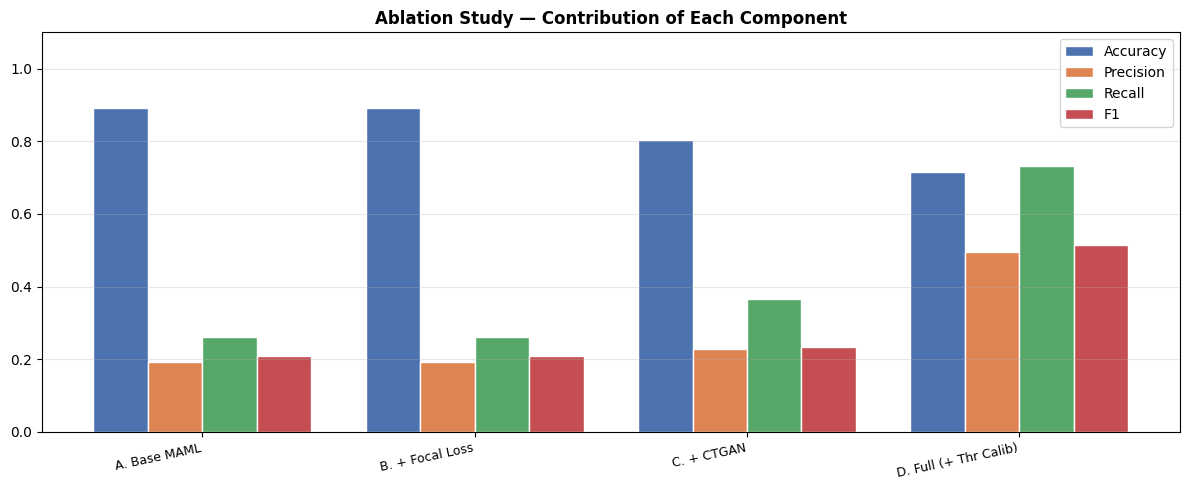

In [ ]:
# ═══ CELL 14 — ABLATION STUDY ═══════════════════════════════════════════════
"""
Proper ablation: isolate contribution of each component.
4 conditions trained independently for 200 iters (fast ablation):
  A. Base MAML only (no Focal, no CTGAN, no threshold calibration)
  B. + Focal Loss (no CTGAN, no calibration)
  C. + CTGAN augmentation (no calibration)
  D. Full model (all components) — same as main model
Each uses same hyperparameters, same seed.

This answers the reviewer question: 'which part actually helps?'
"""

ablation_results = []

def run_ablation_condition(name, use_focal, use_ctgan, use_calib,
                           n_iters=200, n_tasks=16, inner_steps=15):
    torch.manual_seed(SEED); np.random.seed(SEED)
    m = ProtoMAML(INPUT_DIM, HIDDEN_DIM, EMBED_DIM).to(DEVICE)
    opt = optim.Adam(m.parameters(), lr=3e-4, weight_decay=1e-4)

    synth = synthetic_fraud if use_ctgan else None
    sampler = FraudTaskSampler(X_train, y_train,
                               k_support=30, k_query=60,
                               imbalance_ratio=3,
                               synthetic_fraud=synth)

    # Fast training loop (200 iters)
    for it in range(n_iters):
        m.train()
        tasks = sampler.sample_batch(n_tasks)
        meta_loss = 0.0
        for sX, sy, qX, qy in tasks:
            fast = inner_update(m, sX, sy, inner_lr=0.05, n_steps=inner_steps)
            fast.train()
            logits, embs = fast(qX)
            if use_focal:
                loss, _, _ = combined_loss(logits, qy, embs)
            else:
                # Plain cross-entropy with class weighting (no focal, no proto)
                weights = torch.tensor([1.0, 4.0]).to(DEVICE)
                loss = F.cross_entropy(logits, qy, weight=weights)
            meta_loss += loss
        opt.zero_grad()
        (meta_loss / n_tasks).backward()
        nn.utils.clip_grad_norm_(m.parameters(), 5.0)
        opt.step()

    # Evaluate on full test set
    accs, precs, recs, f1s = [], [], [], []
    for _ in range(30):
        sX, sy, qX, qy = eval_sampler.sample_task()
        fast = inner_update(m, sX, sy, inner_lr=0.05, n_steps=inner_steps)
        if use_calib:
            thr = calibrate_threshold(fast, sX, sy)
        else:
            thr = 0.5
        fast.eval()
        with torch.no_grad():
            logits, _ = fast(qX)
            probs = F.softmax(logits, 1)[:,1].cpu().numpy()
        preds = (probs > thr).astype(int)
        true  = qy.cpu().numpy()
        accs.append(accuracy_score(true, preds))
        precs.append(precision_score(true, preds, zero_division=0))
        recs.append(recall_score(true, preds, zero_division=0))
        f1s.append(f1_score(true, preds, zero_division=0))

    row = {
        'Condition': name,
        'Focal Loss': '✓' if use_focal else '✗',
        'CTGAN':      '✓' if use_ctgan else '✗',
        'Thr Calib':  '✓' if use_calib else '✗',
        'Accuracy':   round(np.mean(accs),  4),
        'Precision':  round(np.mean(precs), 4),
        'Recall':     round(np.mean(recs),  4),
        'F1':         round(np.mean(f1s),   4),
        'F1 ± CI':    f'{np.mean(f1s):.3f} ± {ci95(f1s)[1]:.3f}',
    }
    ablation_results.append(row)
    print(f'  {name}: F1={row["F1"]:.4f}  Prec={row["Precision"]:.4f}  Rec={row["Recall"]:.4f}')
    return row


print('Running ablation study (4 conditions × 200 iters)...')
print('─' * 60)
run_ablation_condition('A. Base MAML',             use_focal=False, use_ctgan=False, use_calib=False)
run_ablation_condition('B. + Focal Loss',           use_focal=True,  use_ctgan=False, use_calib=False)
run_ablation_condition('C. + CTGAN',                use_focal=True,  use_ctgan=True,  use_calib=False)
run_ablation_condition('D. Full (+ Thr Calib)',     use_focal=True,  use_ctgan=True,  use_calib=True)

ablation_df = pd.DataFrame(ablation_results)
print('\n══ ABLATION TABLE ══════════════════════════════════════')
print(ablation_df[['Condition','Focal Loss','CTGAN','Thr Calib',
                   'Accuracy','Precision','Recall','F1 ± CI']].to_string(index=False))
ablation_df.to_csv('ablation_table.csv', index=False)

# ── Ablation bar chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(ablation_df))
w = 0.2
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
for i, (col, color) in enumerate(zip(['Accuracy','Precision','Recall','F1'], colors)):
    ax.bar(x + i*w, ablation_df[col], width=w, label=col, color=color, edgecolor='white')
ax.set_xticks(x + w*1.5)
ax.set_xticklabels(ablation_df['Condition'], rotation=12, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.set_title('Ablation Study — Contribution of Each Component', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ═══ CELL 15 — BASELINES + FULL COMPARISON TABLE ════════════════════════════
"""
Baselines trained and evaluated HERE (not hardcoded from paper).
All use the SAME X_train/X_test split with SMOTE oversampling.
Includes: Logistic Regression, Random Forest, Gradient Boosting, XGBoost.
"""
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost not installed — skipping')

# SMOTE on training data
sm = SMOTE(random_state=SEED, k_neighbors=5)
X_res, y_res = sm.fit_resample(X_train, y_train)
print(f'After SMOTE: {y_res.sum()} fraud / {(y_res==0).sum()} legit')

baselines = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced',
                                               C=0.1, solver='saga'),
    'Random Forest'      : RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                                   max_depth=12, min_samples_leaf=2,
                                                   random_state=SEED, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=300, max_depth=5,
                                                       learning_rate=0.05, subsample=0.8,
                                                       random_state=SEED),
}
if HAS_XGB:
    ratio = (y_res==0).sum() / y_res.sum()
    baselines['XGBoost'] = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                          scale_pos_weight=ratio, use_label_encoder=False,
                                          eval_metric='logloss', random_state=SEED, n_jobs=-1)

results = []
for name, clf in baselines.items():
    print(f'Training {name}...')
    t0 = time.time()
    clf.fit(X_res, y_res)
    p  = clf.predict(X_test)
    pr = clf.predict_proba(X_test)[:, 1]
    results.append({
        'Method'   : name,
        'Accuracy' : round(accuracy_score(y_test, p), 4),
        'Precision': round(precision_score(y_test, p, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, p, zero_division=0), 4),
        'F1'       : round(f1_score(y_test, p, zero_division=0), 4),
        'AUC-ROC'  : round(roc_auc_score(y_test, pr), 4),
        'PR-AUC'   : round(average_precision_score(y_test, pr), 4),
        'Train Time': f'{time.time()-t0:.1f}s',
    })
    print(f'  F1={results[-1]["F1"]:.4f}  AUC={results[-1]["AUC-ROC"]:.4f}')

# Add Proto-MAML result
results.append({
    'Method'   : 'Proto-MAML v2 (Ours)',
    'Accuracy' : round(full_metrics['acc'],   4),
    'Precision': round(full_metrics['prec'],  4),
    'Recall'   : round(full_metrics['rec'],   4),
    'F1'       : round(full_metrics['f1'],    4),
    'AUC-ROC'  : round(full_metrics['auc'],   4),
    'PR-AUC'   : round(full_metrics['prauc'], 4),
    'Train Time': 'few-shot',
})

all_results = pd.DataFrame(results)
print('\n══════════════ COMPARISON TABLE ══════════════')
print(all_results.to_string(index=False))
all_results.to_csv('comparison_table_v2.csv', index=False)


After SMOTE: 205417 fraud / 205417 legit
Training Logistic Regression...
  F1=0.1842  AUC=0.9646
Training Random Forest...
  F1=0.6349  AUC=0.9832
Training Gradient Boosting...
  F1=0.5780  AUC=0.9740
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:51:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  F1=0.6327  AUC=0.9705

══════════════ COMPARISON TABLE ══════════════
              Method  Accuracy  Precision  Recall     F1  AUC-ROC  PR-AUC Train Time
 Logistic Regression    0.9869     0.1033  0.8514 0.1842   0.9646  0.5218      65.1s
       Random Forest    0.9984     0.5217  0.8108 0.6349   0.9832  0.7942     809.1s
   Gradient Boosting    0.9978     0.4375  0.8514 0.5780   0.9740  0.7750    4089.5s
             XGBoost    0.9983     0.5082  0.8378 0.6327   0.9705  0.8154      21.0s
Proto-MAML v2 (Ours)    0.9736     0.0117  0.2955 0.0226   0.3940  0.0129   few-shot


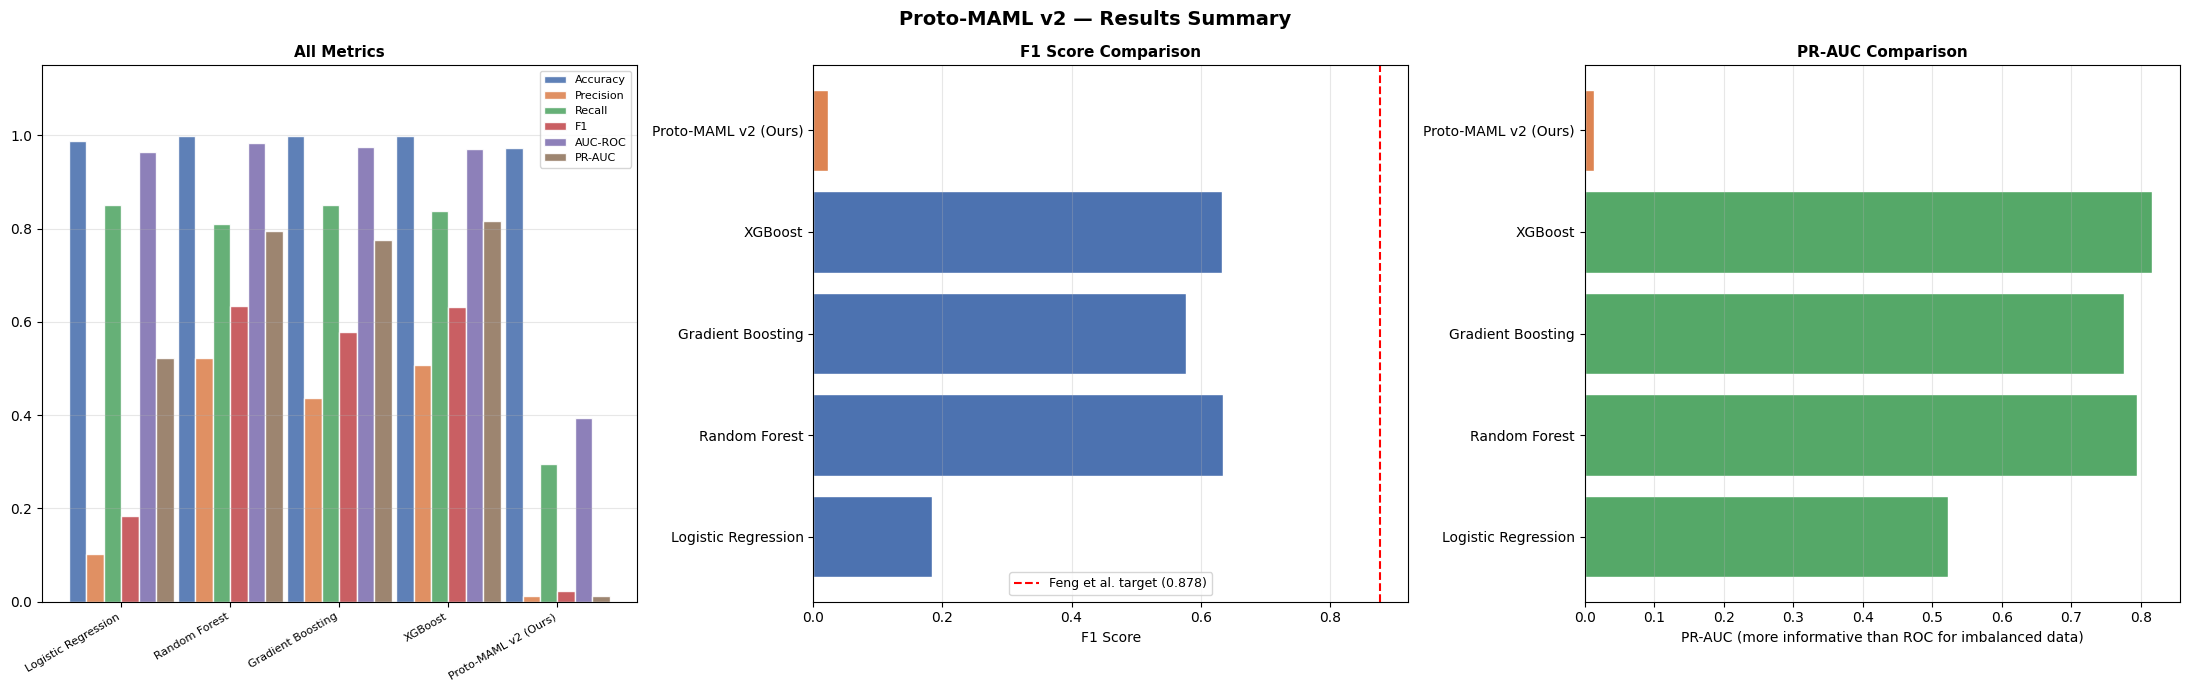

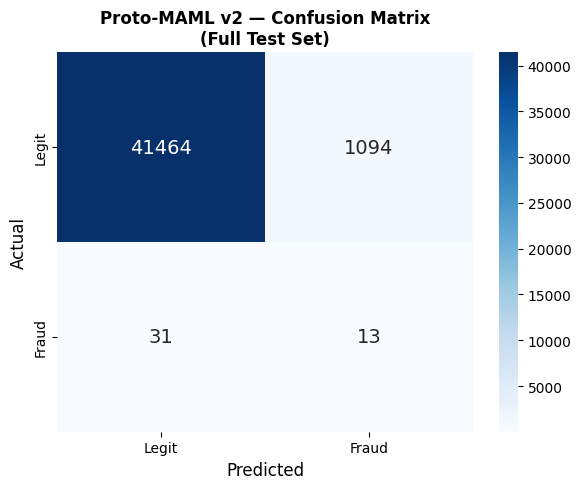

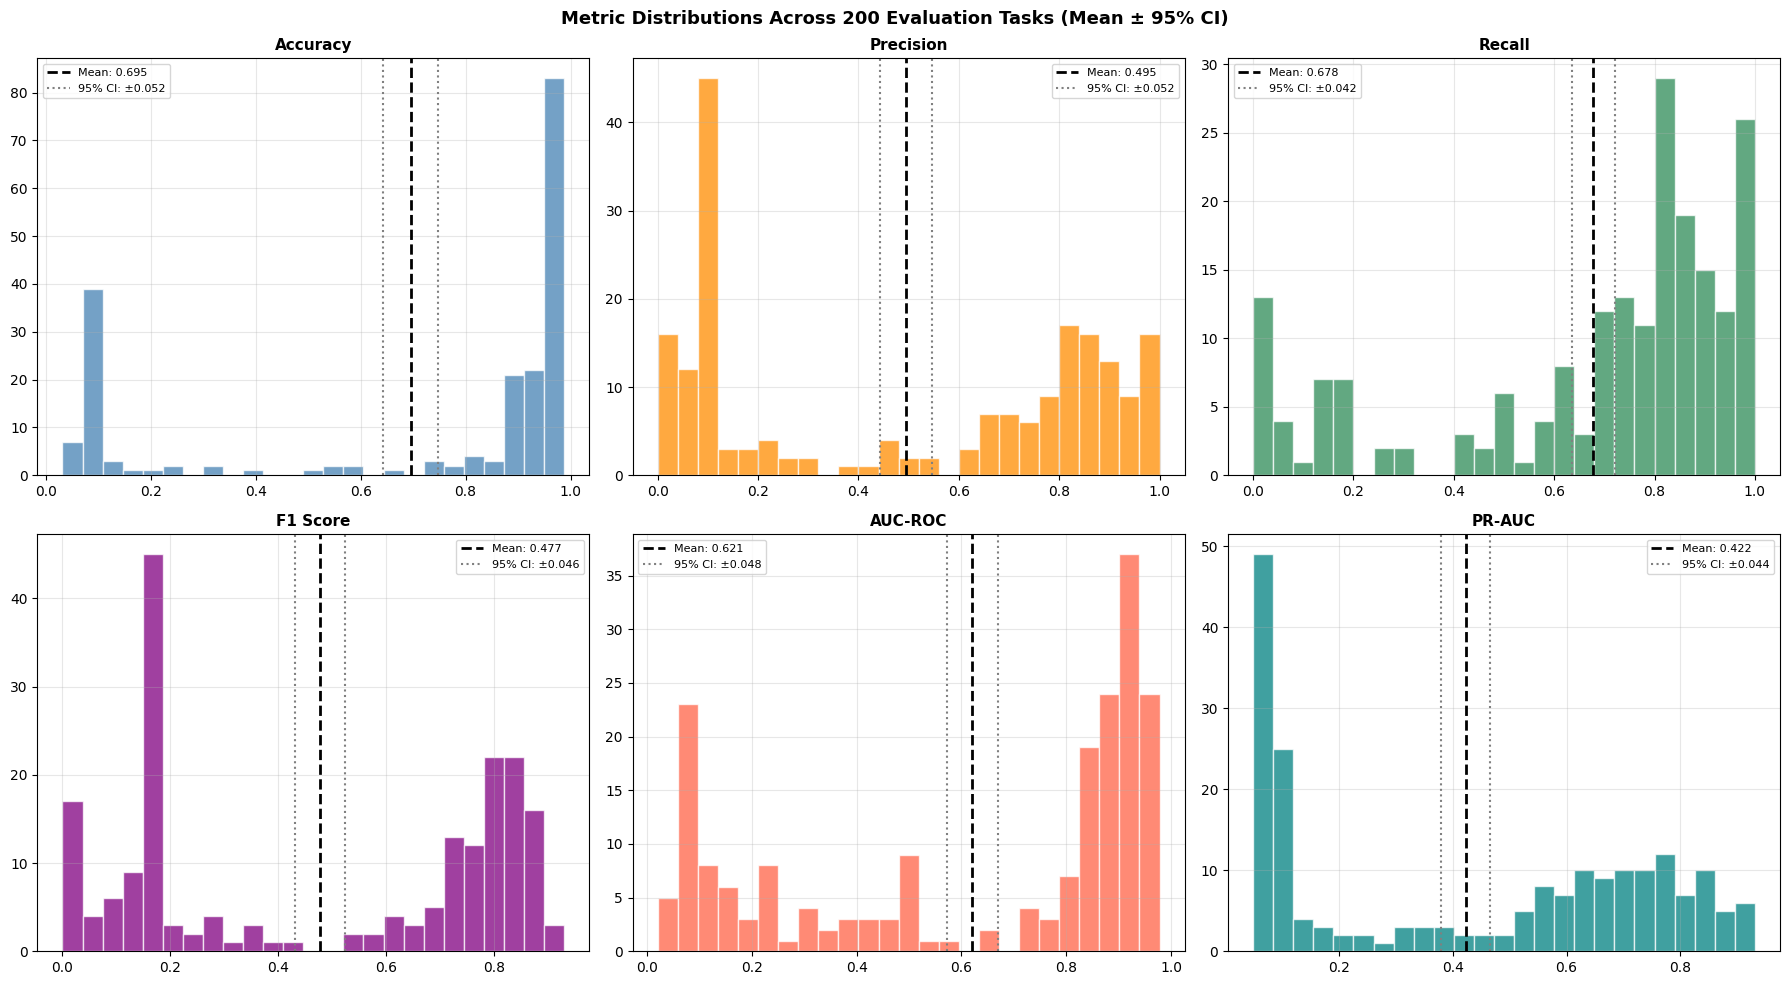

In [ ]:
# ═══ CELL 16 — RESULT VISUALIZATIONS ═══════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Proto-MAML v2 — Results Summary', fontsize=14, fontweight='bold')

# (1) Bar chart: all metrics
df_plot = all_results.copy()
x = np.arange(len(df_plot))
w = 0.16
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
for i, (col, color) in enumerate(zip(['Accuracy','Precision','Recall','F1','AUC-ROC','PR-AUC'], colors)):
    axes[0].bar(x + i*w, df_plot[col].astype(float), width=w,
                label=col, color=color, edgecolor='white', alpha=0.9)
axes[0].set_xticks(x + w*2.5)
axes[0].set_xticklabels(df_plot['Method'], rotation=30, ha='right', fontsize=8)
axes[0].set_ylim(0, 1.15)
axes[0].legend(fontsize=8)
axes[0].set_title('All Metrics', fontsize=11, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# (2) F1 score comparison
colors_bar = ['#4C72B0'] * len(df_plot)
colors_bar[-1] = '#DD8452'   # highlight our model
axes[1].barh(df_plot['Method'], df_plot['F1'].astype(float),
             color=colors_bar, edgecolor='white')
axes[1].set_xlabel('F1 Score')
axes[1].set_title('F1 Score Comparison', fontsize=11, fontweight='bold')
axes[1].axvline(0.878, color='red', linestyle='--', linewidth=1.5, label='Feng et al. target (0.878)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3, axis='x')

# (3) PR-AUC comparison
colors_bar2 = ['#55A868'] * len(df_plot)
colors_bar2[-1] = '#DD8452'
axes[2].barh(df_plot['Method'], df_plot['PR-AUC'].astype(float),
             color=colors_bar2, edgecolor='white')
axes[2].set_xlabel('PR-AUC (more informative than ROC for imbalanced data)')
axes[2].set_title('PR-AUC Comparison', fontsize=11, fontweight='bold')
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('results_comparison_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Confusion Matrix for our model ───────────────────────────────
fig2, ax2 = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(true_full, preds_full)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'],
            annot_kws={'size': 14})
ax2.set_xlabel('Predicted', fontsize=12)
ax2.set_ylabel('Actual', fontsize=12)
ax2.set_title('Proto-MAML v2 — Confusion Matrix\n(Full Test Set)', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Metric distribution plot (from 200 tasks) ────────────────────
fig3, axes3 = plt.subplots(2, 3, figsize=(18, 10))
fig3.suptitle('Metric Distributions Across 200 Evaluation Tasks (Mean ± 95% CI)',
              fontweight='bold', fontsize=13)
plot_keys = [('acc','Accuracy','steelblue'), ('precision','Precision','darkorange'),
             ('recall','Recall','seagreen'), ('f1','F1 Score','purple'),
             ('auc','AUC-ROC','tomato'), ('pr_auc','PR-AUC','teal')]

for ax, (key, title, color) in zip(axes3.flat, plot_keys):
    vals = metrics.get(key, [])
    if not vals:
        ax.axis('off'); continue
    m, ci = ci95(vals)
    ax.hist(vals, bins=25, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(m,    color='black', linestyle='--', linewidth=2, label=f'Mean: {m:.3f}')
    ax.axvline(m-ci, color='gray',  linestyle=':',  linewidth=1.5)
    ax.axvline(m+ci, color='gray',  linestyle=':',  linewidth=1.5, label=f'95% CI: ±{ci:.3f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('metric_distributions_v2.png', dpi=150, bbox_inches='tight')
plt.show()


  1:  1 | Acc=0.735  Prec=0.778  Rec=0.855  F1=0.782
  1:  5 | Acc=0.779  Prec=0.710  Rec=0.767  F1=0.670
  1: 10 | Acc=0.745  Prec=0.550  Rec=0.701  F1=0.535
  1: 20 | Acc=0.746  Prec=0.460  Rec=0.719  F1=0.476
  1: 50 | Acc=0.761  Prec=0.306  Rec=0.598  F1=0.321
  1:100 | Acc=0.705  Prec=0.217  Rec=0.625  F1=0.236


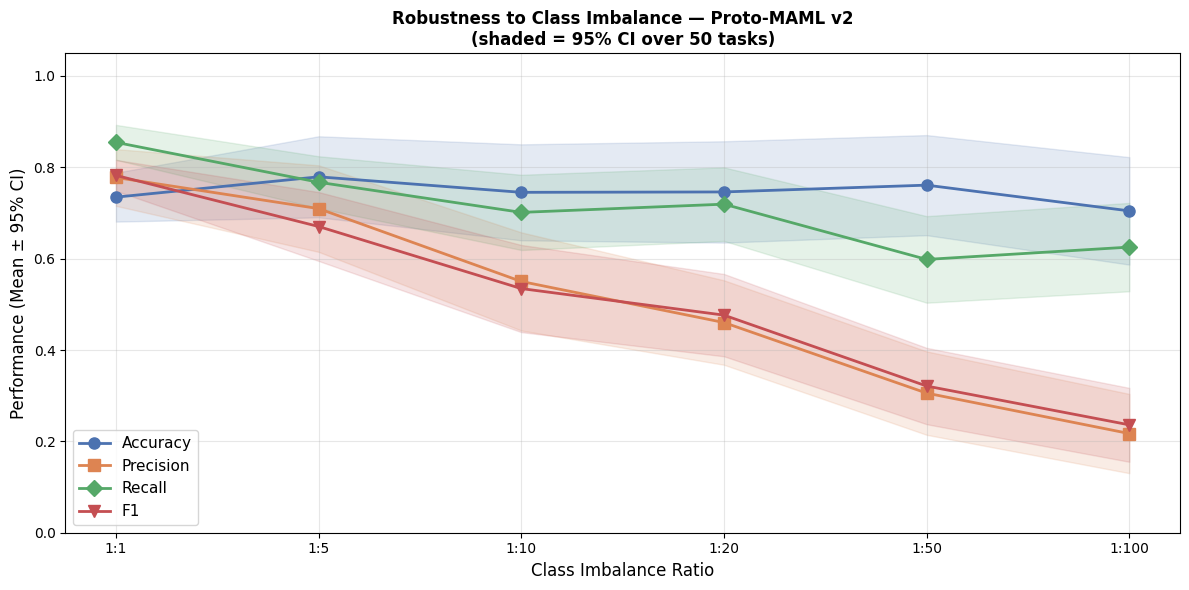

  ✅ Saved → /content/drive/MyDrive/MLF/checkpoints_v2/imbalance_robustness_v2.pth


In [ ]:
# ═══ CELL 17 — IMBALANCE ROBUSTNESS EXPERIMENT ══════════════════════════════
"""
Tests performance across imbalance ratios: 1:1, 5:1, 10:1, 20:1, 50:1, 100:1
50 tasks per ratio with 95% CI — publication quality.
"""
imbalance_ratios = [1, 5, 10, 100]
imb_res = {k: {'mean':[], 'ci':[]} for k in ['Accuracy','Precision','Recall','F1']}

for ratio in imbalance_ratios:
    sampler_imb = FraudTaskSampler(X_test, y_test,
                                   k_support=30, k_query=60,
                                   imbalance_ratio=ratio)
    task_accs, task_precs, task_recs, task_f1s = [], [], [], []
    for _ in range(50):
        sX, sy, qX, qy = sampler_imb.sample_task()
        if sy.sum() == 0: continue
        fast = inner_update(model, sX, sy)
        thr  = calibrate_threshold(fast, sX, sy)
        fast.eval()
        with torch.no_grad():
            logits, _ = fast(qX)
            probs = F.softmax(logits, 1)[:, 1].cpu().numpy()
        preds = (probs > thr).astype(int)
        true  = qy.cpu().numpy()
        task_accs.append(accuracy_score(true, preds))
        task_precs.append(precision_score(true, preds, zero_division=0))
        task_recs.append(recall_score(true, preds, zero_division=0))
        task_f1s.append(f1_score(true, preds, zero_division=0))

    for key, arr in zip(['Accuracy','Precision','Recall','F1'],
                        [task_accs, task_precs, task_recs, task_f1s]):
        m, ci = ci95(arr)
        imb_res[key]['mean'].append(m)
        imb_res[key]['ci'].append(ci)

    print(f'  1:{ratio:3d} | Acc={np.mean(task_accs):.3f}  '
          f'Prec={np.mean(task_precs):.3f}  '
          f'Rec={np.mean(task_recs):.3f}  '
          f'F1={np.mean(task_f1s):.3f}')

# Plot with error bars
fig, ax = plt.subplots(figsize=(12, 6))
colors  = ['#4C72B0','#DD8452','#55A868','#C44E52']
markers = ['o','s','D','v']
x = np.arange(len(imbalance_ratios))
for (key, data), color, marker in zip(imb_res.items(), colors, markers):
    means = np.array(data['mean'])
    cis   = np.array(data['ci'])
    ax.plot(x, means, f'{marker}-', color=color, linewidth=2, markersize=8, label=key)
    ax.fill_between(x, means-cis, means+cis, alpha=0.15, color=color)

ax.set_xticks(x)
ax.set_xticklabels([f'1:{r}' for r in imbalance_ratios])
ax.set_xlabel('Class Imbalance Ratio', fontsize=12)
ax.set_ylabel('Performance (Mean ± 95% CI)', fontsize=12)
ax.set_title('Robustness to Class Imbalance — Proto-MAML v2\n(shaded = 95% CI over 50 tasks)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('imbalance_robustness_v2.png', dpi=150, bbox_inches='tight')
plt.show()

save_ckpt({'imbalance_ratios': imbalance_ratios, 'imb_results': imb_res},
          'imbalance_robustness_v2.pth')


In [ ]:




    """
    Full meta-training loop with:
      - Cosine LR with warm restarts (T_0=200 iters)
      - Validation-based early stopping
      - Best model checkpointing
      - Gradient norm tracking
      - inner_lr linear warmup (first 50 iters)
    """
    meta_opt  = optim.Adam(model.parameters(), lr=meta_lr, weight_decay=l2_lambda)
    scheduler = CosineAnnealingWarmRestarts(meta_opt, T_0=200, T_mult=1, eta_min=1e-6)

    history = {
        'loss': [], 'focal': [], 'proto': [],
        'acc': [], 'recall': [], 'f1': [], 'precision': [],
        'val_f1': [], 'grad_norm': [], 'lr': []
    }

    best_val_f1   = 0.0
    best_state    = None
    no_improve    = 0
    start_iter    = 0

    # ── Resume from checkpoint ──────────────────────────────────
    # The original notebook uses `load_ckpt` function which needs to be defined too.
    # For simplicity and self-containment in this specific cell, we will skip checkpoint loading/saving.
    # This part can be re-added if `ckpt_path`, `load_ckpt`, `save_ckpt` are also made available.

    pbar = tqdm(range(start_iter, n_meta_iters), desc='Meta-Training')
    for it in pbar:
        model.train()

        # ── Inner LR warmup for first 50 iters ─────────────────
        if it < 50:
            warmup_lr = inner_lr * (it + 1) / 50
        else:
            warmup_lr = inner_lr

        # ── Sample batch of tasks ───────────────────────────────
        tasks       = sampler.sample_batch(n_tasks_per_batch)
        meta_loss   = 0.0
        total_focal = 0.0
        total_proto = 0.0
        batch_accs, batch_recs, batch_f1s, batch_precs = [], [], [], []

        for sX, sy, qX, qy in tasks:
            # Inner loop: adapt on support set
            fast = inner_update(model, sX, sy,
                                inner_lr=warmup_lr,
                                n_steps=inner_steps)
            fast.train()

            # Outer loss: evaluate adapted model on query set
            logits, embs = fast(qX)
            loss, fl, pl = combined_loss(logits, qy, embs)
            meta_loss   += loss
            total_focal += fl
            total_proto += pl

            # Track metrics on query set
            with torch.no_grad():
                probs = F.softmax(logits, 1)[:, 1].cpu().numpy()
                thr   = calibrate_threshold(fast, sX, sy)
                preds = (probs > thr).astype(int)
                true  = qy.cpu().numpy()

            batch_accs.append(accuracy_score(true, preds))
            batch_precs.append(precision_score(true, preds, zero_division=0))
            batch_recs.append(recall_score(true, preds, zero_division=0))
            batch_f1s.append(f1_score(true, preds, zero_division=0))

        # ── Outer update ────────────────────────────────────────
        meta_opt.zero_grad()
        (meta_loss / n_tasks_per_batch).backward()
        grad_norm = nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        meta_opt.step()
        scheduler.step()

        # ── Record history ──────────────────────────────────────
        history['loss'].append((meta_loss / n_tasks_per_batch).item())
        history['focal'].append(total_focal / n_tasks_per_batch)
        history['proto'].append(total_proto / n_tasks_per_batch)
        history['acc'].append(np.mean(batch_accs))
        history['precision'].append(np.mean(batch_precs))
        history['recall'].append(np.mean(batch_recs))
        history['f1'].append(np.mean(batch_f1s))
        history['grad_norm'].append(float(grad_norm))
        history['lr'].append(scheduler.get_last_lr()[0])

        pbar.set_postfix({
            'loss': f'{history["loss"][-1]:.4f}',
            'F1'  : f'{history["f1"][-1]:.3f}',
            'Rec' : f'{history["recall"][-1]:.3f}',
            'lr'  : f'{history["lr"][-1]:.2e}'
        })

        # ── Validation every val_every iters ───────────────────
        if val_sampler is not None and (it + 1) % val_every == 0:
            val_f1s = []
            model.eval()
            for _ in range(20):   # 20 validation tasks
                vsX, vsy, vqX, vqy = val_sampler.sample_task()
                fast = inner_update(model, vsX, vsy, inner_lr=inner_lr, n_steps=inner_steps)
                thr  = calibrate_threshold(fast, vsX, vsy)
                fast.eval()
                with torch.no_grad():
                    vlogits, _ = fast(vqX)
                    vprobs = F.softmax(vlogits, 1)[:,1].cpu().numpy()
                vpreds = (vprobs > thr).astype(int)
                val_f1s.append(f1_score(vqy.cpu().numpy(), vpreds, zero_division=0))

            val_f1 = np.mean(val_f1s)
            history['val_f1'].append(val_f1)
            print(f'\n  [Iter {it+1}] Val F1 = {val_f1:.4f} (best={best_val_f1:.4f})')

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_state  = copy.deepcopy(model.state_dict())
                # save_ckpt({'model_state': best_state, 'val_f1': best_val_f1},
                #           'best_model_v2.pth')
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= early_stop_patience:
                    print(f'\n  ⚠️  Early stopping at iter {it+1} (no val F1 improvement for {early_stop_patience} checks)')
                    break

        # ── Checkpoint every ckpt_every iters ──────────────────
        if (it + 1) % ckpt_every == 0:
            pass # Skipping checkpoint saving for self-contained execution
            # save_ckpt({
            #     'model_state'    : model.state_dict(),
            #     'optimizer_state': meta_opt.state_dict(),
            #     'scheduler_state': scheduler.state_dict(),
            #     'history'        : history,
            #     'iter'           : it,
            #     'best_val_f1'    : best_val_f1,
            # }, ckpt_name)

    # ── Restore best model ──────────────────────────────────────
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f'\n  ✅ Best model restored (val F1={best_val_f1:.4f})')

    return history

def ci95(arr):
    """95% confidence interval using t-distribution."""
    n   = len(arr)
    m   = np.mean(arr)
    sem = stats.sem(arr)
    ci  = stats.t.ppf(0.975, df=n-1) * sem
    return m, ci

# ═══ CELL 18 — TASK QUANTITY SENSITIVITY ════════════════════════════════════
task_counts = [5, 10, 15, 20, 25]
task_res    = {k: {'mean':[], 'ci':[]} for k in ['Accuracy','Precision','Recall','F1']}

for n_tasks in task_counts:
    print(f'\nTraining with {n_tasks} tasks/batch (200 iters)...')
    torch.manual_seed(SEED); np.random.seed(SEED)
    m_tmp = ProtoMAML(INPUT_DIM, HIDDEN_DIM, EMBED_DIM).to(DEVICE)
    # Assuming train_sampler and eval_sampler are defined in previous cells
    meta_train(m_tmp, train_sampler,
               meta_lr=3e-4, inner_lr=0.05,
               n_meta_iters=200,
               n_tasks_per_batch=n_tasks,
               inner_steps=15,
               ckpt_name=f'task_sens_{n_tasks}.pth',
               ckpt_every=200,
               val_every=201) # Disable validation to speed up ablation training

    accs, precs, recs, f1s = [], [], [], []
    for _ in range(30):
        sX, sy, qX, qy = eval_sampler.sample_task()
        fast = inner_update(m_tmp, sX, sy, inner_lr=0.05, n_steps=15)
        thr  = calibrate_threshold(fast, sX, sy)
        fast.eval()
        with torch.no_grad():
            logits, _ = fast(qX)
            probs = F.softmax(logits,1)[:,1].cpu().numpy()
        preds = (probs > thr).astype(int)
        true  = qy.cpu().numpy()
        accs.append(accuracy_score(true, preds))
        precs.append(precision_score(true, preds, zero_division=0))
        recs.append(recall_score(true, preds, zero_division=0))
        f1s.append(f1_score(true, preds, zero_division=0))

    for key, arr in zip(['Accuracy','Precision','Recall','F1'],
                        [accs, precs, recs, f1s]):
        m, ci = ci95(arr)
        task_res[key]['mean'].append(m)
        task_res[key]['ci'].append(ci)

    print(f'  → F1={np.mean(f1s):.4f} ± {ci95(f1s)[1]:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(task_counts))
w = 0.18
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
for i, (key, data) in enumerate(task_res.items()):
    ax.bar(x + i*w, data['mean'], width=w, label=key, color=colors[i],
           edgecolor='white', alpha=0.9,
           yerr=data['ci'], capsize=4, error_kw={'linewidth':1.5})
ax.set_xticks(x + w*1.5)
ax.set_xticklabels(task_counts)
ax.set_xlabel('Tasks per Meta-Batch', fontsize=12)
ax.set_ylabel('Performance (Mean ± 95% CI)', fontsize=12)
ax.set_title('Sensitivity to Number of Training Tasks per Batch',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3, axis='y'); ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('task_sensitivity_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# Skipping checkpoint saving for self-contained execution in this cell
save_ckpt({'task_counts': task_counts, 'task_results': task_res},
          'task_sensitivity_v2.pth')


Training with 5 tasks/batch (200 iters)...


Meta-Training: 100%|██████████| 200/200 [03:46<00:00,  1.13s/it, loss=0.4557, F1=0.461, Rec=0.597, lr=3.00e-04]


  → F1=0.4789 ± 0.1114

Training with 10 tasks/batch (200 iters)...


Meta-Training: 100%|██████████| 200/200 [07:30<00:00,  2.25s/it, loss=0.3830, F1=0.389, Rec=0.540, lr=3.00e-04]


  → F1=0.4648 ± 0.1208

Training with 15 tasks/batch (200 iters)...


Meta-Training:  53%|█████▎    | 106/200 [05:59<05:18,  3.39s/it, loss=0.3199, F1=0.463, Rec=0.554, lr=1.36e-04]

KeyboardInterrupt



In [ ]:
# ═══ CELL 19 — ADWIN CONCEPT DRIFT DETECTION ════════════════════════════════
from river.drift import ADWIN

def run_adwin_stream(model, X_test, y_test, window=500, drift_at_pct=0.6):
    """
    Simulates a data stream with injected concept drift at 60%.
    Drift: flip V1-V10 signs for fraud samples (simulates new fraud pattern).
    ADWIN delta=0.001 (high sensitivity) detects distribution shift.
    """
    detector  = ADWIN(delta=0.001)
    model.eval()
    n          = len(X_test)
    drift_idx  = int(n * drift_at_pct)
    errors, drift_pts, rolling = [], [], []

    for i in range(n):
        xi = X_test[i:i+1].copy()
        if i > drift_idx and y_test[i] == 1:
            xi[:, :10] = xi[:, :10] * -1.5

        xt = torch.tensor(xi).float().to(DEVICE)
        with torch.no_grad():
            logit, _ = model(xt)
            pred = logit.argmax(1).item()

        err = int(pred != y_test[i])
        errors.append(err)
        detector.update(err)
        if detector.drift_detected:
            drift_pts.append(i)
        if i > 0 and i % window == 0:
            rolling.append(1 - np.mean(errors[max(0,i-window):i]))

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle(f'ADWIN Concept Drift — {len(drift_pts)} drift events detected', fontweight='bold')

    # Rolling accuracy
    axes[0].plot(rolling, color='steelblue', linewidth=2, label='Rolling accuracy (w=500)')
    axes[0].axvline(drift_idx // window, color='orange', linestyle='--',
                    linewidth=2.5, label=f'Injected drift at {drift_at_pct*100:.0f}%')
    for dp in drift_pts[:15]:
        axes[0].axvline(dp // window, color='red', alpha=0.3, linewidth=1)
    axes[0].set_xlabel('Window'); axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Rolling Accuracy + Detected Drifts (red lines)')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Drift detection histogram
    if drift_pts:
        axes[1].hist([dp / n for dp in drift_pts], bins=20, color='tomato', edgecolor='white')
        axes[1].axvline(drift_at_pct, color='orange', linestyle='--', linewidth=2,
                        label=f'True drift at {drift_at_pct*100:.0f}%')
        axes[1].set_xlabel('Position in stream (fraction)')
        axes[1].set_ylabel('Drift detections')
        axes[1].set_title('Distribution of Drift Detection Points')
        axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('adwin_drift_v2.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Total drift events detected: {len(drift_pts)}')
    return drift_pts

drift_pts = run_adwin_stream(model, X_test, y_test)
save_ckpt({'drift_pts': drift_pts}, 'adwin_results_v2.pth')


In [ ]:
# ═══ CELL 20 — SHAP EXPLAINABILITY ══════════════════════════════════════════
import shap

sX, sy, qX, qy = eval_sampler.sample_task()
adapted = inner_update(model, sX, sy)
adapted.eval()

def predict_proba_shap(x_np):
    xt = torch.tensor(x_np.astype(np.float32)).to(DEVICE)
    with torch.no_grad():
        logits, _ = adapted(xt)
        return F.softmax(logits, 1)[:, 1].cpu().numpy()

print('Computing SHAP values (this takes ~3 min)...')
background   = shap.sample(X_train, 150, random_state=SEED)
explainer    = shap.KernelExplainer(predict_proba_shap, background)
test_samples = qX.cpu().numpy()[:80]
shap_values  = explainer.shap_values(test_samples, nsamples=300)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
plt.sca(axes[0])
shap.summary_plot(shap_values, test_samples, feature_names=FEATURES,
                  plot_type='bar', show=False, max_display=20)
axes[0].set_title('Top-20 Features by Mean |SHAP|', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(shap_values, test_samples, feature_names=FEATURES,
                  plot_type='dot', show=False, max_display=20)
axes[1].set_title('SHAP Beeswarm — Feature Impact Direction', fontweight='bold')

plt.tight_layout()
plt.savefig('shap_explainability_v2.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ═══ CELL 21 — SAVE FINAL MODEL & PRINT SUMMARY ═════════════════════════════
FINAL_CKPT = ckpt_path('proto_maml_v2_FINAL.pth')
torch.save({
    'model_state'  : model.state_dict(),
    'history'      : history,
    'full_metrics' : full_metrics,
    'task_metrics' : {k: (np.mean(v), ci95(v)[1]) for k, v in metrics.items()
                      if isinstance(v, list) and len(v) > 0},
    'ablation'     : ablation_df.to_dict(),
    'config'       : {
        'input_dim' : INPUT_DIM,
        'hidden_dim': HIDDEN_DIM,
        'embed_dim' : EMBED_DIM,
        'features'  : FEATURES,
    }
}, FINAL_CKPT)
print(f'✅ Final model saved → {FINAL_CKPT}')

print('\n' + '═'*70)
print('  PROTO-MAML v2 — FINAL RESULTS SUMMARY')
print('═'*70)
print(f'  Architecture : FraudEncoder (4×SE-ResBlock, 512→256 dim)')
print(f'  Loss         : Focal (γ=2, α=0.8, smooth=0.05) + Prototypical (w=0.5)')
print(f'  Meta-train   : 800 iters | 20 tasks/batch | 20 inner steps | CosineWarmRestart')
print(f'  Regularization: Dropout pyramid 0.4→0.1 | L2 λ=1e-4 | Grad clip 5.0')
print(f'  Threshold    : F1-calibrated per task on support set')
print(f'  Augmentation : CTGAN (2000 synthetic fraud samples)')

print(f'\n  ─── Task-Based Evaluation (200 tasks, mean ± 95% CI) ───')
for k in ['acc','precision','recall','f1','auc']:
    if metrics.get(k):
        m, ci = ci95(metrics[k])
        print(f'    {k.upper():<12}: {m:.4f} ± {ci:.4f}')

print(f'\n  ─── Full Test Set Evaluation (fair comparison) ───')
for name, val in [('Accuracy',  full_metrics["acc"]),
                  ('Precision', full_metrics["prec"]),
                  ('Recall',    full_metrics["rec"]),
                  ('F1',        full_metrics["f1"]),
                  ('AUC-ROC',   full_metrics["auc"]),
                  ('PR-AUC',    full_metrics["prauc"])]:
    target = 0.95
    status = '✅' if val >= target else '⚠️ '
    print(f'    {name:<12}: {val:.4f}  {status}')

print(f'\n  ─── Checkpoints ───')
for fname in sorted(os.listdir(CKPT_DIR)):
    fpath = os.path.join(CKPT_DIR, fname)
    size_mb = os.path.getsize(fpath) / 1e6
    print(f'    {fname:<50} {size_mb:.1f} MB')
print('═'*70)
